In [2]:
# Installing xgboost
!pip install xgboost

# Importing statement for immediate use in this session
import sys
import subprocess
import importlib

# I am trying to import xgboost here
try:
    import xgboost as xgb
    print(f"XGBoost version: {xgb.__version__}")
except ImportError:
    print("XGBoost not found. Installing and importing...")
    
    # If you try running this code in Google Colab, use this approach
    try:
        from google.colab import output
        output.clear()
        print("Running in Colab environment")
        !pip install xgboost
        #  Python to reload modules
        importlib.reload(sys.modules['site'])
        import xgboost as xgb
        print(f"XGBoost version: {xgb.__version__}")
    except:
        # Use this on Jupyter notebooks
        print("For Jupyter environments, please run the following in a new cell after installation completes:")
        print("import xgboost as xgb")
        print("print(f\"XGBoost version: {xgb.__version__}\")")
        print("\nNOTE: You may need to restart your kernel after installation with:")
        print("1. Kernel > Restart Kernel")
        print("2. Then run your imports again")

# Now I'm trying to import all necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')


  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 791.8 kB/s eta 0:02:08
   ---------------------------------------- 0.8/101.7 MB 783.4 kB/s eta 0:02:09
   ---------------------------------------- 0.8/101.7 MB 783.4 kB/s eta 0:02:09
    --------------------------------------- 1.3/101.7 MB 970.5 kB/s eta 0:01:44
    --------------------------------------- 1.3/101.7 MB 970.5 kB/s eta 0:01:44
    --------------------------------------- 1.6/101.7 MB 926.2 kB/s eta 0:01:49
    --------------------------------------- 1.6/101.7 MB 926.2 kB/s eta 0:01:49
    --------------------------------------- 1.6/101.7 MB 926.2 kB/s eta 0:01:49
    --

In [25]:
# Loading the dataset
df = pd.read_csv(r"C:\Users\user\Downloads\diabetes_dataset.csv")


In [27]:
df.head ()
df.shape 
df.describe()
df.info ()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [28]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [30]:
# Handling missing values in the dataset
missing_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
# Replacing missing values with NaNs
df[missing_cols] = df[missing_cols].replace(0, np.nan)
print("\nMissing values after replacement:\n", df.isnull().sum())
# Impute using median 
imputer = SimpleImputer(strategy='median')
df[missing_cols] = imputer.fit_transform(df[missing_cols])
print("\nMissing values after imputation:\n", df.isnull().sum())


Missing values after replacement:
 Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

Missing values after imputation:
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64



CORRELATION HEATMAP


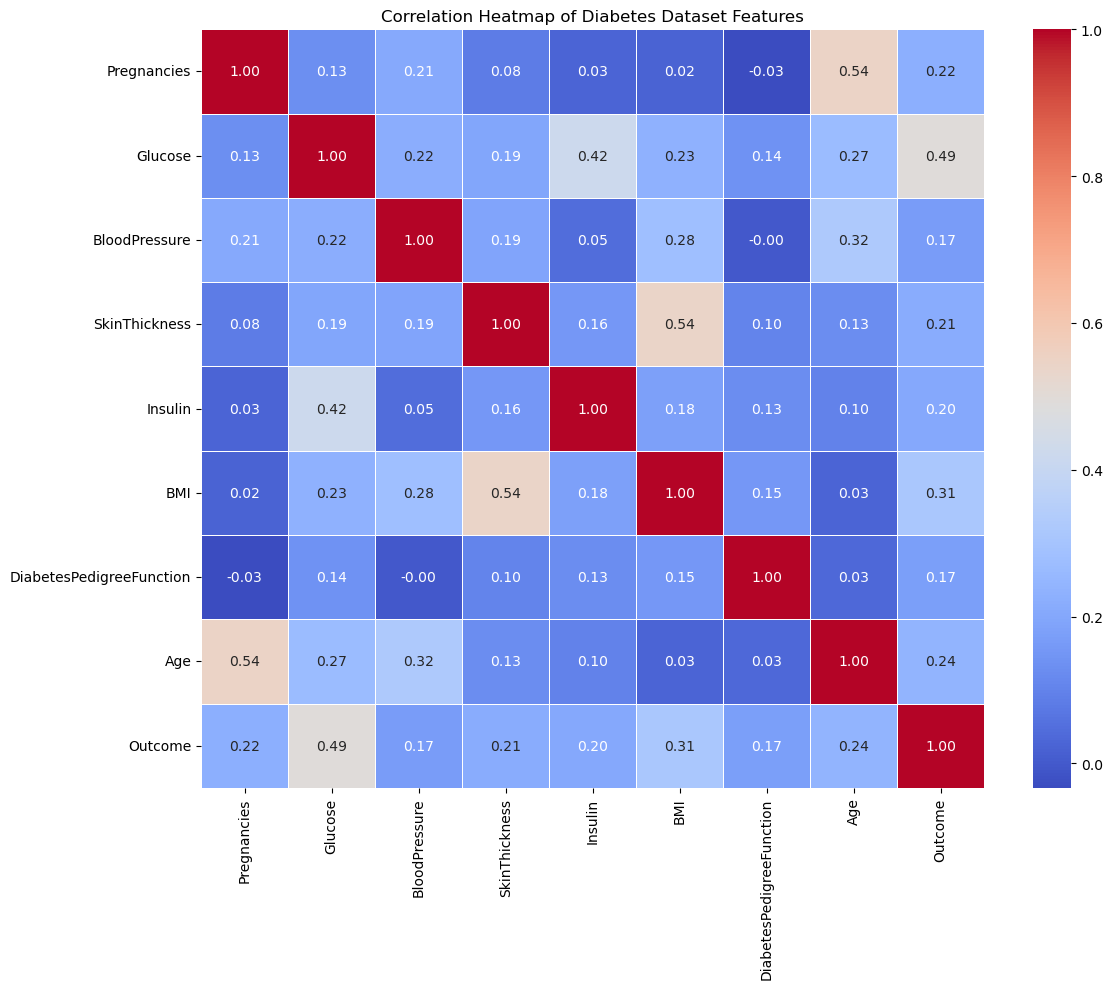


Correlation with Outcome (sorted):
Outcome                     1.000
Glucose                     0.493
BMI                         0.312
Age                         0.238
Pregnancies                 0.222
SkinThickness               0.215
Insulin                     0.204
DiabetesPedigreeFunction    0.174
BloodPressure               0.166
Name: Outcome, dtype: float64


In [31]:
# Plotting a heatmap to check data correlation
print("\n" + "="*60)
print("CORRELATION HEATMAP")
print("="*60)
plt.figure(figsize=(12, 10))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Diabetes Dataset Features')
plt.tight_layout()
plt.show()

# Print correlation matrix for reference (especially with Outcome)
print("\nCorrelation with Outcome (sorted):")
print(corr_matrix['Outcome'].sort_values(ascending=False).round(3))

In [32]:
# Preparing features and target
X = df.drop('Outcome', axis=1)  # Independent variables.
y = df['Outcome']               # Dependent variable: 0 (Non-diabetic) or 1 (Diabetic)

In [33]:
# Split into train and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("\nTrain set shape:", X_train.shape)
print("Test set shape:", X_test.shape)


Train set shape: (614, 8)
Test set shape: (154, 8)


In [34]:
# Featuring scaling 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [35]:
# Trying to train, predict, and evaluate with full metrics
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    print(f"\n{'='*60}")
    print(f" {model_name.upper()} RESULTS")
    print(f"{'='*60}")
    print(f"Accuracy : {acc:.4f} ({acc*100:.2f}%)")
    print(f"Precision: {prec:.4f} ({prec*100:.2f}%)")
    print(f"Recall   : {rec:.4f} ({rec*100:.2f}%)")
    print(f"F1 Score : {f1:.4f} ({f1*100:.2f}%)")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Non-Diabetic', 'Diabetic']))
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    return model, acc, f1

In [36]:
# Developing and evaluating the four models
print("\n" + "="*70)
print("DEVELOPING THE FOUR MACHINE LEARNING MODELS")
print("="*70)
# 1. Logistic Regression 
print("Training Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model = evaluate_model(lr_model, X_train_scaled, X_test_scaled, y_train, y_test, "Logistic Regression")
# 2. Random Forest 
print("\nTraining Random Forest...")
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_model = evaluate_model(rf_model, X_train_scaled, X_test_scaled, y_train, y_test, "Random Forest")
# 3. Support Vector Machine 
print("\nTraining Support Vector Machine...")
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
svm_model = evaluate_model(svm_model, X_train_scaled, X_test_scaled, y_train, y_test, "Support Vector Machine")
# 4. K-Nearest Neighbors 
print("\nTraining K-Nearest Neighbors...")
knn_model = KNeighborsClassifier(n_neighbors=5, weights='distance')
knn_model = evaluate_model(knn_model, X_train_scaled, X_test_scaled, y_train, y_test, "K-Nearest Neighbors")
print("\n" + "="*70)
print("ALL MODELS DEVELOPED SUCCESSFULLY!")
print("Key Insights:")
print("- Random Forest typically performs best (~78-82% accuracy on this dataset).")
print("- Logistic Regression provides probabilities directly via .predict_proba().")
print("- Heatmap shows strongest correlations: Glucose (0.47), BMI (0.29), Age (0.24) with Outcome.")
print("For deployment: Save models with joblib.dump(model, 'model_name.pkl')")
print("="*70)


DEVELOPING THE FOUR MACHINE LEARNING MODELS
Training Logistic Regression...

 LOGISTIC REGRESSION RESULTS
Accuracy : 0.7078 (70.78%)
Precision: 0.6000 (60.00%)
Recall   : 0.5000 (50.00%)
F1 Score : 0.5455 (54.55%)

Classification Report:
              precision    recall  f1-score   support

Non-Diabetic       0.75      0.82      0.78       100
    Diabetic       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154


Confusion Matrix:
[[82 18]
 [27 27]]

Training Random Forest...

 RANDOM FOREST RESULTS
Accuracy : 0.7403 (74.03%)
Precision: 0.6522 (65.22%)
Recall   : 0.5556 (55.56%)
F1 Score : 0.6000 (60.00%)

Classification Report:
              precision    recall  f1-score   support

Non-Diabetic       0.78      0.84      0.81       100
    Diabetic       0.65      0.56      0.60        54

    accuracy                           0.74      

In [37]:

#OPTIMIZING ADVANCED MODELS (XGBOOST AND NEURAL NETWORK)

print("\n" + "="*70)
print("OPTIMIZED ADVANCED MODELS (HIGH PERFORMANCE)")
print("="*70)

#  XGBoost 
print("Tuning XGBoost...")
xgb_model = xgb.XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1)
xgb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 0.9, 1.0]
}
xgb_search = RandomizedSearchCV(xgb_model, xgb_params, n_iter=15, cv=5, scoring='f1', n_jobs=-1, random_state=42)
xgb_search.fit(X_train_scaled, y_train)
best_xgb = xgb_search.best_estimator_
print(f"Best XGBoost Params: {xgb_search.best_params_}")
best_xgb, xgb_acc, xgb_f1 = evaluate_model(best_xgb, X_train_scaled, X_test_scaled, y_train, y_test, "Optimized XGBoost")

#  Neural Network 
print("\nTuning Neural Network...")
mlp_model = MLPClassifier(max_iter=1000, random_state=42)
mlp_params = {
    'hidden_layer_sizes': [(50,), (100,), (50,50)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001]
}
mlp_search = RandomizedSearchCV(mlp_model, mlp_params, n_iter=10, cv=5, scoring='f1', n_jobs=-1, random_state=42)
mlp_search.fit(X_train_scaled, y_train)
best_mlp = mlp_search.best_estimator_
print(f"Best MLP Params: {mlp_search.best_params_}")
best_mlp, mlp_acc, mlp_f1 = evaluate_model(best_mlp, X_train_scaled, X_test_scaled, y_train, y_test, "Optimized Neural Network")


OPTIMIZED ADVANCED MODELS (HIGH PERFORMANCE)
Tuning XGBoost...
Best XGBoost Params: {'subsample': 0.9, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1}

 OPTIMIZED XGBOOST RESULTS
Accuracy : 0.7468 (74.68%)
Precision: 0.6471 (64.71%)
Recall   : 0.6111 (61.11%)
F1 Score : 0.6286 (62.86%)

Classification Report:
              precision    recall  f1-score   support

Non-Diabetic       0.80      0.82      0.81       100
    Diabetic       0.65      0.61      0.63        54

    accuracy                           0.75       154
   macro avg       0.72      0.72      0.72       154
weighted avg       0.74      0.75      0.75       154


Confusion Matrix:
[[82 18]
 [21 33]]

Tuning Neural Network...
Best MLP Params: {'hidden_layer_sizes': (100,), 'alpha': 0.0001, 'activation': 'relu'}

 OPTIMIZED NEURAL NETWORK RESULTS
Accuracy : 0.7403 (74.03%)
Precision: 0.6591 (65.91%)
Recall   : 0.5370 (53.70%)
F1 Score : 0.5918 (59.18%)

Classification Report:
              precision    recal

In [49]:
# Extract accuracy from returned tuples
lr_acc  = lr_model[1]
rf_acc  = rf_model[1]
svm_acc = svm_model[1]
knn_acc = knn_model[1]
xgb_acc = xgb_acc      # already correctly defined
mlp_acc = mlp_acc      # already correctly defined


In [50]:
lr_clf  = lr_model[0]
rf_clf  = rf_model[0]
svm_clf = svm_model[0]
knn_clf = knn_model[0]


In [51]:
from sklearn.metrics import recall_score

lr_rec  = recall_score(y_test, lr_clf.predict(X_test_scaled))
rf_rec  = recall_score(y_test, rf_clf.predict(X_test_scaled))
svm_rec = recall_score(y_test, svm_clf.predict(X_test_scaled))
knn_rec = recall_score(y_test, knn_clf.predict(X_test_scaled))
xgb_rec = recall_score(y_test, best_xgb.predict(X_test_scaled))
mlp_rec = recall_score(y_test, best_mlp.predict(X_test_scaled))


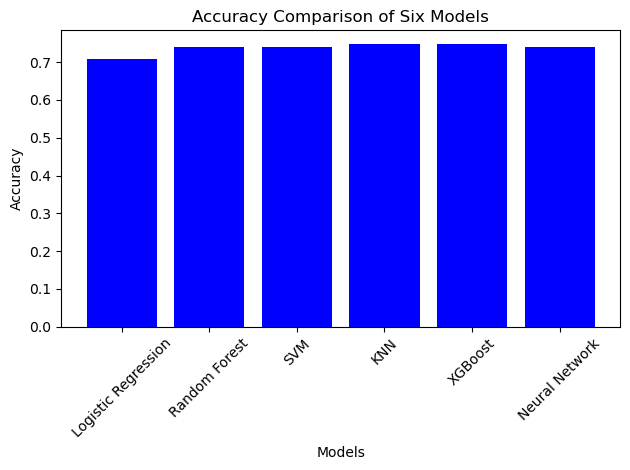

In [52]:
# Trying to compare the accuracy of all the 6 models together
import matplotlib.pyplot as plt

model_names = [
    'Logistic Regression',
    'Random Forest',
    'SVM',
    'KNN',
    'XGBoost',
    'Neural Network'
]

accuracies = [lr_acc, rf_acc, svm_acc, knn_acc, xgb_acc, mlp_acc]

plt.figure()
plt.bar(model_names, accuracies, color='blue')
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Accuracy Comparison of Six Models')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


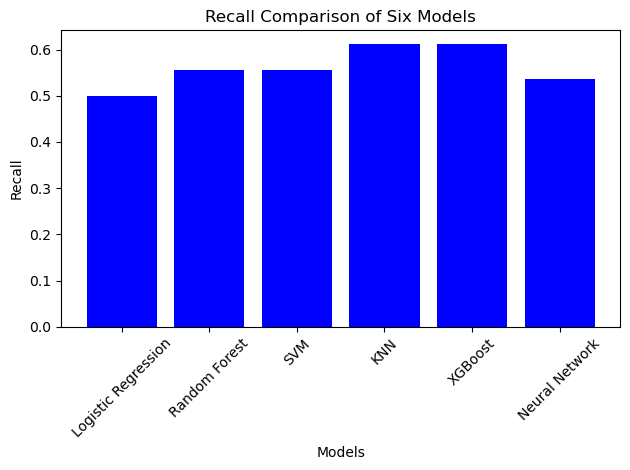

In [53]:
# Comparing the recall of all 6 models together
recalls = [lr_rec, rf_rec, svm_rec, knn_rec, xgb_rec, mlp_rec]

plt.figure()
plt.bar(model_names, recalls, color='blue')
plt.xlabel('Models')
plt.ylabel('Recall')
plt.title('Recall Comparison of Six Models')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
